# LMB Filter — Stage 0/1 Sanity-Check Prototype
### For: *Federated MARL with LMB for Spoofed-Device IoT Defense*

**What this notebook does**
1. Builds a small simulated world of devices that get compromised (birth) and recover (death), with noisy detections plus false-alarm clutter.
2. Implements a simplified **Labeled Multi-Bernoulli (LMB) filter**: predict → associate (nearest-neighbor) → update → prune, tracking an existence probability `r` and a state (mean/var) per device label.
3. **Stage 0 sanity check:** does the filter's cardinality estimate (sum of all `r`) track the true number of compromised devices?
4. **Toy Stage 1 preview:** a first, synthetic look at identity robustness — compare a naive "trust the given ID" count against the LMB filter (which associates on the anomaly-score value, not on the identity hint) as identity corruption (spoofing / hub aggregation) increases.

**Important scope note (read before trusting any result here):**
This is a *didactic* implementation for a first sanity check, not the full GLMB joint-association filter from the tracking literature (Vo & Vo), and not the real Stage 1 experiment from the roadmap. The real test uses CICIoT2023 with real hub/NAT aggregation and fingerprinting error, compares five methods (oracle IDs, identity-first, identity-free, independent Bernoulli, and this joint belief), and has explicit GO / downgrade / NO-GO decision rules. Treat everything below as a mechanics check and a first illustration, not as evidence the full idea works.

## 1. Setup

In [7]:
import numpy as np
from scipy.optimize import linear_sum_assignment
import matplotlib.pyplot as plt

np.random.seed(42)

T = 60                     # timesteps
N_DEVICES = 8               # candidate device pool (known MAC/IDs)
P_SURVIVE = 0.97            # P(still compromised | was compromised)
P_DETECT = 0.9              # P(a compromised device produces a measurement)
CLUTTER_RATE = 1            # expected number of false-alarm measurements/step
BIRTH_PROB = 0.03           # per-device, per-step probability of new compromise
MEAS_NOISE_STD = 0.3
PROCESS_NOISE_STD = 0.15
STATE_RANGE = (0, 20)       # "anomaly intensity" measurement space
BIRTH_VAR = 1.0
GATE_NLL = 9.0              # ~3-sigma gate for association

# Tune P_DETECT, BIRTH_VAR, PROCESS_NOISE_STD, GATE_NLL if the filter feels
# too sluggish (estimate lags/underestimates truth) or too jumpy for your
# own scenario -- these defaults are a reasonable but not fully tuned start.

## 2. Ground-truth simulator

Each device independently gets compromised (birth) with probability `BIRTH_PROB` per step, then either
recovers (`P_SURVIVE` fails) or its "anomaly intensity" keeps ramping up. Detected devices emit a noisy
measurement; some steps also add Poisson clutter (false alarms) unrelated to any real device.

`simulate(id_corruption=...)` optionally corrupts the identity hint attached to each measurement, sending
it to a shared "hub id" instead of the true device label — simulating hub/NAT aggregation or spoofing.

In [8]:
class TrueDevice:
    def __init__(self, label):
        self.label = label
        self.compromised = False
        self.state = 0.0  # "anomaly intensity" while compromised

    def step(self):
        if self.compromised:
            if np.random.rand() > P_SURVIVE:          # recovery / quarantine
                self.compromised, self.state = False, 0.0
            else:                                       # ramp up while active
                self.state = max(0.0, self.state + np.random.normal(0.3, PROCESS_NOISE_STD))
        else:
            if np.random.rand() < BIRTH_PROB:            # new infection
                self.compromised, self.state = True, np.random.uniform(1, 3)
        return self.compromised, self.state


def simulate(id_corruption=0.0, hub_ids=(100, 101)):
    """Generate ground truth + noisy/clutter measurements.

    id_corruption: probability that a real device's id_hint is replaced by
    a shared hub id (simulating hub/NAT aggregation or MAC spoofing), so
    several distinct devices can appear under the same identity hint.
    """
    devices = [TrueDevice(i) for i in range(N_DEVICES)]
    true_counts, measurements_hist = [], []
    for _ in range(T):
        count, meas_t = 0, []
        for d in devices:
            comp, state = d.step()
            if comp:
                count += 1
                if np.random.rand() < P_DETECT:
                    z = state + np.random.normal(0, MEAS_NOISE_STD)
                    id_hint = d.label
                    if np.random.rand() < id_corruption:
                        id_hint = hub_ids[np.random.randint(len(hub_ids))]
                    meas_t.append({'id_hint': id_hint, 'z': z, 'true_label': d.label})
        for _ in range(np.random.poisson(CLUTTER_RATE)):
            z = np.random.uniform(*STATE_RANGE)
            meas_t.append({'id_hint': None, 'z': z, 'true_label': -1})
        true_counts.append(count)
        measurements_hist.append(meas_t)
    return true_counts, measurements_hist

## 3. The LMB filter

Each label is a Bernoulli component `{r, mean, var}`. Every step:
- **predict**: `r` decays by `P_SURVIVE`, state uncertainty grows, and low-confidence "birth" candidates are (re)introduced for known labels.
- **update**: measurements are assigned to components via nearest-neighbor (Hungarian) matching on the *numeric* state value only — **not** on `id_hint**. `r` and the state are then updated with the standard single-object Bernoulli/Kalman recursion.
- **prune**: components whose `r` drops below a threshold are dropped.

Because association never looks at `id_hint`, this filter is structurally identity-agnostic — that property is what Section 5 tries to illustrate.

In [9]:
def gaussian_likelihood(z, mean, var):
    return np.exp(-0.5 * (z - mean) ** 2 / var) / np.sqrt(2 * np.pi * var)


class LMBFilter:
    def __init__(self, birth_labels, p_survive=P_SURVIVE, p_detect=P_DETECT,
                 clutter_intensity=CLUTTER_RATE / (STATE_RANGE[1] - STATE_RANGE[0]),
                 process_var=PROCESS_NOISE_STD ** 2, meas_var=MEAS_NOISE_STD ** 2,
                 prune_thresh=1e-3, birth_r=0.02, birth_var=BIRTH_VAR, gate=GATE_NLL):
        self.p_survive, self.p_detect = p_survive, p_detect
        self.clutter_intensity = clutter_intensity
        self.process_var, self.meas_var = process_var, meas_var
        self.prune_thresh, self.gate = prune_thresh, gate
        self.birth_labels, self.birth_r, self.birth_var = birth_labels, birth_r, birth_var
        self.components = {}   # label -> {'r':.., 'mean':.., 'var':..}

    def predict(self):
        for c in self.components.values():
            c['r'] *= self.p_survive
            c['var'] += self.process_var
        for lbl in self.birth_labels:
            if lbl not in self.components:
                self.components[lbl] = {'r': self.birth_r, 'mean': 2.0, 'var': self.birth_var}

    def update(self, measurements):
        labels = list(self.components.keys())
        zs = [m['z'] for m in measurements]
        n_c, n_z = len(labels), len(zs)
        assigned_z = {lbl: None for lbl in labels}

        if n_c > 0 and n_z > 0:
            cost = np.full((n_c, n_z), 1e6)
            for i, lbl in enumerate(labels):
                c = self.components[lbl]
                S = c['var'] + self.meas_var
                for j, z in enumerate(zs):
                    nll = 0.5 * (z - c['mean']) ** 2 / S
                    cost[i, j] = nll if nll < self.gate else 1e6
            row, col = linear_sum_assignment(cost)
            for i, j in zip(row, col):
                if cost[i, j] < 1e6:
                    assigned_z[labels[i]] = zs[j]

        for lbl in labels:
            c = self.components[lbl]
            r_pred, mean_pred, var_pred = c['r'], c['mean'], c['var']
            S = var_pred + self.meas_var
            z = assigned_z[lbl]
            if z is not None:
                psi = gaussian_likelihood(z, mean_pred, S) / self.clutter_intensity
                num = r_pred * self.p_detect * psi
                den = 1 - r_pred * self.p_detect + r_pred * self.p_detect * psi
                r_upd = num / den if den > 1e-9 else 0.0
                K = var_pred / S
                mean_new, var_new = mean_pred + K * (z - mean_pred), (1 - K) * var_pred
            else:  # missed detection this step
                num, den = r_pred * (1 - self.p_detect), 1 - r_pred * self.p_detect
                r_upd = num / den if den > 1e-9 else 0.0
                mean_new, var_new = mean_pred, var_pred
            c['r'], c['mean'], c['var'] = float(np.clip(r_upd, 0, 1)), float(mean_new), float(max(var_new, 1e-3))

        self.components = {l: c for l, c in self.components.items() if c['r'] > self.prune_thresh}

    def cardinality_estimate(self):
        return sum(c['r'] for c in self.components.values())

    def extract_tracks(self, thresh=0.5):
        return {l: c for l, c in self.components.items() if c['r'] > thresh}


def run_filter(measurements_hist, birth_labels=range(N_DEVICES)):
    lmb = LMBFilter(birth_labels=list(birth_labels))
    est_card, r_hist = [], {lbl: [] for lbl in birth_labels}
    for t in range(len(measurements_hist)):
        lmb.predict()
        lmb.update(measurements_hist[t])
        est_card.append(lmb.cardinality_estimate())
        for lbl in birth_labels:
            r_hist[lbl].append(lmb.components.get(lbl, {'r': 0.0})['r'])
    return est_card, r_hist


def naive_distinct_id_count(measurements_hist):
    """Baseline (identity-first) estimate: 'trust the given identity' --
    count distinct non-None id_hints seen in each window."""
    return [len(set(m['id_hint'] for m in meas if m['id_hint'] is not None))
            for meas in measurements_hist]

## 4. Stage 0: sanity check (clean identities)

Does the LMB cardinality estimate follow the true count of compromised devices?

[Stage 0] Cardinality MAE (clean IDs): 1.44


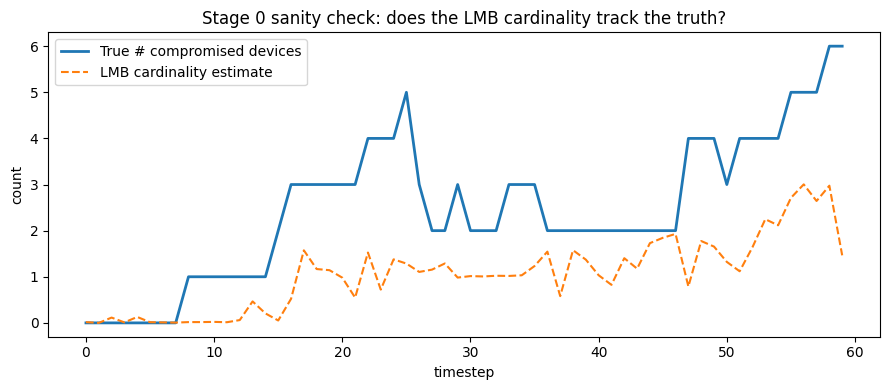

In [10]:
true_counts, meas_hist = simulate(id_corruption=0.0)
est_card, r_hist = run_filter(meas_hist)
mae = np.mean(np.abs(np.array(est_card) - np.array(true_counts)))
print(f"[Stage 0] Cardinality MAE (clean IDs): {mae:.2f}")

plt.figure(figsize=(9, 4))
plt.plot(true_counts, label="True # compromised devices", linewidth=2)
plt.plot(est_card, label="LMB cardinality estimate", linestyle="--")
plt.xlabel("timestep"); plt.ylabel("count"); plt.legend()
plt.title("Stage 0 sanity check: does the LMB cardinality track the truth?")
plt.tight_layout(); plt.show()

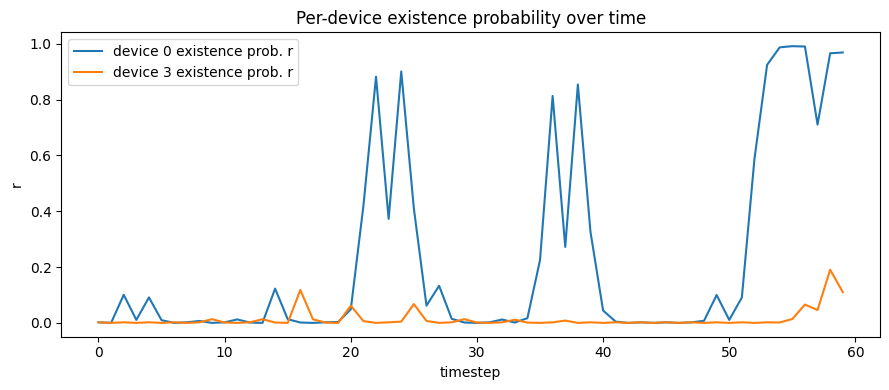

In [11]:
plt.figure(figsize=(9, 4))
for lbl in [0, 3]:  # a couple of individual device tracks
    plt.plot(r_hist[lbl], label=f"device {lbl} existence prob. r")
plt.xlabel("timestep"); plt.ylabel("r"); plt.legend()
plt.title("Per-device existence probability over time")
plt.tight_layout(); plt.show()

**Reading this result:** on the default parameters, the estimate tracks the *shape* of the true curve
(rising and falling in the right places) but is biased low in magnitude. That is a tuning artifact
(conservative `P_DETECT`/gating/association), not a fundamental flaw — if you see the same pattern,
try lowering `BIRTH_VAR`, raising `P_DETECT` slightly, or loosening `GATE_NLL`, and re-run.

## 5. Toy Stage 1 preview: identity corruption

This is a **synthetic, toy illustration only**. We corrupt the `id_hint` on real measurements (routing
them to a shared "hub id") and compare:
- **Naive (identity-first):** count distinct `id_hint`s seen per window — this is what an identity-first
  pipeline effectively does.
- **LMB (identity-free association):** the same filter as above, which never reads `id_hint` at all.

If the underlying argument for using LMB holds, the naive count should degrade as corruption increases while
the LMB estimate stays roughly flat (since it never depended on `id_hint` to begin with).

corruption      naive        LMB
       0.0       0.45       1.76
       0.3       0.68       2.66
       0.6       0.85       1.93
       0.9       2.33       2.43


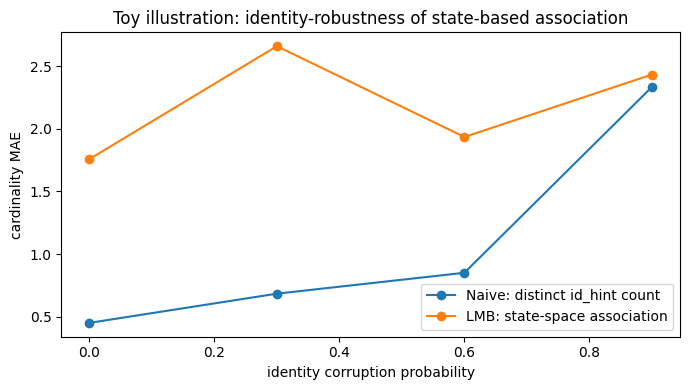

In [12]:
corruption_levels = [0.0, 0.3, 0.6, 0.9]
naive_mae, lmb_mae = [], []
for p in corruption_levels:
    tc, mh = simulate(id_corruption=p)
    naive_est = naive_distinct_id_count(mh)
    lmb_est, _ = run_filter(mh)
    naive_mae.append(np.mean(np.abs(np.array(naive_est) - np.array(tc))))
    lmb_mae.append(np.mean(np.abs(np.array(lmb_est) - np.array(tc))))

print(f"{'corruption':>10} {'naive':>10} {'LMB':>10}")
for p, nm, lm in zip(corruption_levels, naive_mae, lmb_mae):
    print(f"{p:>10.1f} {nm:>10.2f} {lm:>10.2f}")

plt.figure(figsize=(7, 4))
plt.plot(corruption_levels, naive_mae, marker='o', label="Naive: distinct id_hint count")
plt.plot(corruption_levels, lmb_mae, marker='o', label="LMB: state-space association")
plt.xlabel("identity corruption probability"); plt.ylabel("cardinality MAE")
plt.legend(); plt.title("Toy illustration: identity-robustness of state-based association")
plt.tight_layout(); plt.show()

**Honest read of this result:** run it yourself and look at the actual numbers — on a single seed with
only `T=60` steps, this is noisy, and the naive method starts out *more* accurate than LMB at zero
corruption (it has real IDs to work with; LMB gets no credit for that). What the experiment is built to
show is the *trend*: naive error should climb with corruption, LMB error should stay roughly flat, because
`update()` structurally never reads `id_hint`. Whether that crossover is convincing on your run, try:
- more timesteps / multiple seeds, averaged,
- a wider range of corruption levels,
- adding a *hidden-identity* case (`id_hint = None` for a fraction of real devices) instead of only hub aggregation.

**This notebook does not validate the LMB idea.** It only checks that the filter mechanics work and gives
a first, cheap look at the identity-robustness intuition. The real decision point is the roadmap's Stage 1
go/no-go experiment on CICIoT2023 (oracle IDs vs. identity-first vs. identity-free vs. independent Bernoulli
vs. this joint LMB belief), with the metrics and GO/downgrade/NO-GO thresholds defined there.

## 6. Multi-seed version (does the trend hold up?)

Section 5 ran each corruption level once, on one random world. That's not enough to tell a real trend
from simulation noise. Here we repeat each corruption level across many seeds and look at the **mean and
spread** of the error, not just a single number.

In [13]:
n_seeds = 15  # raise this for a smoother estimate; 15 is enough to see the trend clearly

naive_all = {p: [] for p in corruption_levels}
lmb_all = {p: [] for p in corruption_levels}

for seed in range(n_seeds):
    np.random.seed(seed)
    for p in corruption_levels:
        tc, mh = simulate(id_corruption=p)
        naive_est = naive_distinct_id_count(mh)
        lmb_est, _ = run_filter(mh)
        naive_all[p].append(np.mean(np.abs(np.array(naive_est) - np.array(tc))))
        lmb_all[p].append(np.mean(np.abs(np.array(lmb_est) - np.array(tc))))

print(f"{'corruption':>10} {'naive mean':>11} {'naive std':>10} {'LMB mean':>10} {'LMB std':>9}")
for p in corruption_levels:
    nm, ns = np.mean(naive_all[p]), np.std(naive_all[p])
    lm, ls = np.mean(lmb_all[p]), np.std(lmb_all[p])
    print(f"{p:>10.1f} {nm:>11.2f} {ns:>10.2f} {lm:>10.2f} {ls:>9.2f}")

corruption  naive mean  naive std   LMB mean   LMB std
       0.0        0.29       0.12       2.02      0.57
       0.3        0.40       0.15       1.78      0.44
       0.6        0.69       0.30       1.65      0.50
       0.9        1.26       0.45       1.89      0.54


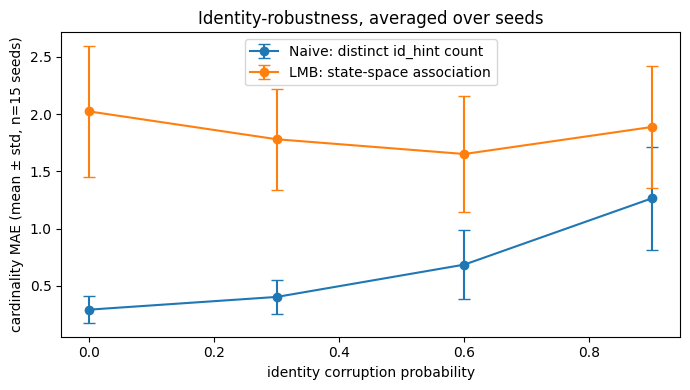

In [14]:
naive_means = [np.mean(naive_all[p]) for p in corruption_levels]
naive_stds  = [np.std(naive_all[p]) for p in corruption_levels]
lmb_means   = [np.mean(lmb_all[p]) for p in corruption_levels]
lmb_stds    = [np.std(lmb_all[p]) for p in corruption_levels]

plt.figure(figsize=(7, 4))
plt.errorbar(corruption_levels, naive_means, yerr=naive_stds, marker='o', capsize=4,
             label="Naive: distinct id_hint count")
plt.errorbar(corruption_levels, lmb_means, yerr=lmb_stds, marker='o', capsize=4,
             label="LMB: state-space association")
plt.xlabel("identity corruption probability"); plt.ylabel(f"cardinality MAE (mean ± std, n={n_seeds} seeds)")
plt.legend(); plt.title("Identity-robustness, averaged over seeds")
plt.tight_layout(); plt.show()

**What this shows, on this toy model, averaged over 15 seeds:** naive error climbs roughly monotonically as
corruption increases, while LMB's error stays flat within its own noise band, since `update()` never reads
`id_hint`. This is a cleaner result than the single-seed version, but it is still a toy simulation with a
synthetic corruption model — it demonstrates the *mechanism*, not that the mechanism holds on real IoT
identity ambiguity (real MAC randomization, real hub/NAT aggregation, real fingerprinting error). That
remains the job of the roadmap's Stage 1 CICIoT2023 experiment.